In [5]:
! pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
   ---------------------------------------- 0.0/240.0 kB ? eta -:--:--
   ---- ---------------------------------- 30.7/240.0 kB 660.6 kB/s eta 0:00:01
   ---------------------------------------- 240.0/240.0 kB 3.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
# imports

import pandas as pd
import numpy as np
import mlflow.sklearn
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("reddit_preprocessed.csv")
df.head()

,clean_comment,category,words,stop_words,characters,punctuation_chars
0,family mormon never tried explain still stare ...,1,39,13,259,0
1,buddhism much lot compatible christianity espe...,1,196,59,1268,0
2,seriously say thing first get complex explain ...,-1,86,40,459,0
3,learned want teach different focus goal not wr...,0,29,15,167,0
4,benefit may want read living buddha living chr...,1,112,45,690,0


In [3]:
import mlflow

mlflow.set_tracking_uri("http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000")

In [4]:
mlflow.set_experiment("Imbalanced Data Handling")

2025/09/24 10:17:37 INFO mlflow.tracking.fluent: Experiment with name 'Imbalanced Data Handling' does not exist. Creating a new experiment.


<Experiment: artifact_location='s3://mlflow-bucket-078/703851687525185618', creation_time=1758719856654, experiment_id='703851687525185618', last_update_time=1758719856654, lifecycle_stage='active', name='Imbalanced Data Handling', tags={}>

In [13]:

def run_experiment_balance_data(sampling_type, df, feature_column, target_column):
    ngram_range = (1,2)
    max_feature = 1000

    vectorizer = TfidfVectorizer(ngram_range=ngram_range, max_features=max_feature)
    vec_name = "TfidfVectorizer"

    X_train, X_test, y_train, y_test = train_test_split(df[feature_column], df[target_column], test_size=0.2, random_state=0)

    X_train = vectorizer.fit_transform(X_train)
    X_test = vectorizer.transform(X_test) # correct way to do it, without data leakage


    if sampling_type == 'class_weights':
        class_weight = 'balanced' # Use class_weight in Random Forest
    else:
        class_weight = None  # Do not apply class_weight if using resampling

        if sampling_type == 'oversampling':
            smote = SMOTE(random_state=0)
            X_train, y_train = smote.fit_resample(X_train, y_train)
        elif sampling_type == 'adasyn':
            adasyn = ADASYN(random_state=0)
            X_train, y_train = adasyn.fit_resample(X_train, y_train)
        elif sampling_type == 'undersampling':
            rus = RandomUnderSampler(random_state=0)
            X_train, y_train = rus.fit_resample(X_train, y_train)
        elif sampling_type == 'smote_enn':
            smote_enn = SMOTEENN(random_state=0)
            X_train, y_train = smote_enn.fit_resample(X_train, y_train)

    with mlflow.start_run() as run:
        
        # Experiments tags
        mlflow.set_tag("mlflow.runName", f"TFIDF_bigrams_imbalance_{sampling_type}")
        mlflow.set_tag("experiment_type", "imbalance_method_comparison")
        mlflow.set_tag("model_type", "RandomForestClassifier")
        mlflow.set_tag("Description", "Experiment to compare the different possible methods of imbalance data handling")

        # parameters for vectorizer and model
        mlflow.log_param("vectorizer_type", vec_name)
        mlflow.log_param("vectorizer_maxfeatures", max_feature)
        mlflow.log_param("vectorizer_ngramrange", ngram_range)

        mlflow.log_param("n_estimators", 200)
        mlflow.log_param("max_depth", 15)
        mlflow.log_param("sampling_type", sampling_type)

        comparison_model = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=0)
        comparison_model.fit(X_train, y_train)
        predictions = comparison_model.predict(X_test)

        comparison_accuracy = accuracy_score(y_test, predictions)

        mlflow.log_metric("accuracy", comparison_accuracy)

        classification_rep = classification_report(y_test, predictions, output_dict=True)

        for label, metrics in classification_rep.items():
            if isinstance(metrics, dict):  # For precision, recall, f1-score, etc.
                for metric, value in metrics.items():
                    mlflow.log_metric(f"{label}_{metric}", value)

        class_names = [-1,0,1]

        # Confusion matrix plot
        conf_matrix = confusion_matrix(y_test, predictions)
        plt.figure(figsize=(8, 6))
        sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title(f"Confusion Matrix - sampling_type: {sampling_type}")

        # Save and log the confusion matrix plot
        plt.savefig(f"conf_matrices/confusion_matrix_sampling_type_{sampling_type}.png")
        mlflow.log_artifact(f"conf_matrices/confusion_matrix_sampling_type_{sampling_type}.png")

        mlflow.sklearn.log_model(comparison_model, f"random_forest_sampling_type_{sampling_type}")

sampling_types = ['class_weights', 'oversampling', 'adasyn', 'undersampling', 'smote_enn']

2025/09/24 10:45:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/24 10:45:24 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_imbalance_class_weights at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618/runs/e56728d25b1b456a98032de95db3c20e
🧪 View experiment at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618


2025/09/24 10:46:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/24 10:46:28 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_imbalance_oversampling at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618/runs/55e049a8dbfc419c91c23254cf8bf587
🧪 View experiment at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618


2025/09/24 10:47:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/24 10:47:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_imbalance_adasyn at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618/runs/e16564ce74144adbb51534a7350da8fa
🧪 View experiment at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618


2025/09/24 10:48:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/24 10:48:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_imbalance_undersampling at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618/runs/1a3f60cd9490452ca2c3ca849217dfd8
🧪 View experiment at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618


2025/09/24 10:49:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/09/24 10:49:26 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run TFIDF_bigrams_imbalance_smote_enn at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618/runs/f1d1bd622fab488c988efe7456c2b1b0
🧪 View experiment at: http://ec2-18-222-216-138.us-east-2.compute.amazonaws.com:5000/#/experiments/703851687525185618


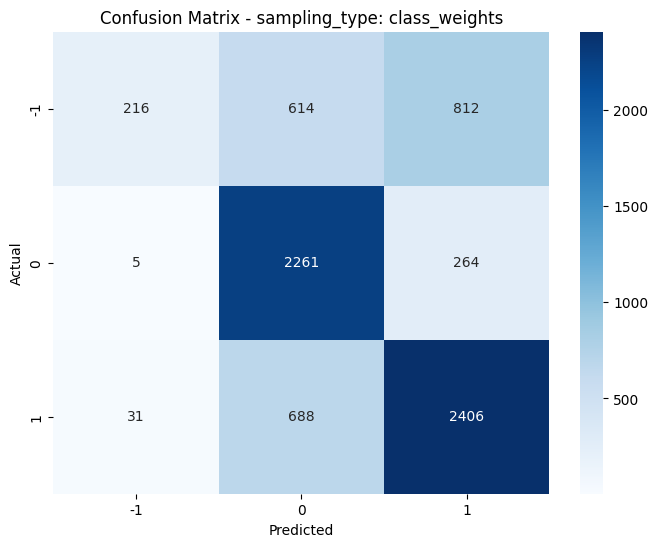

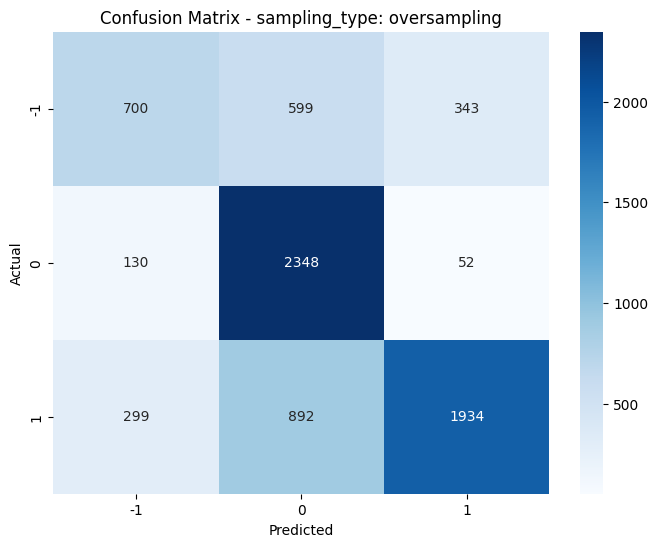

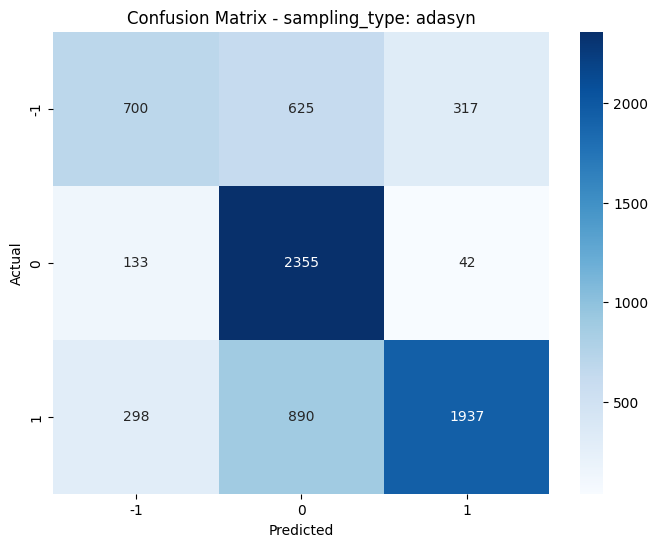

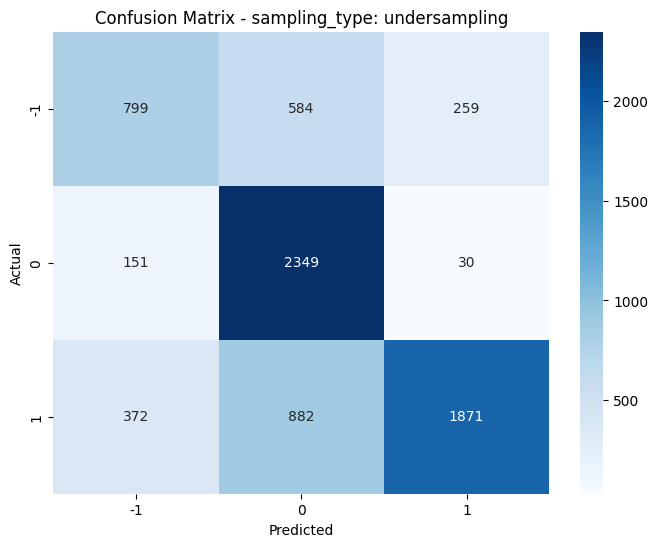

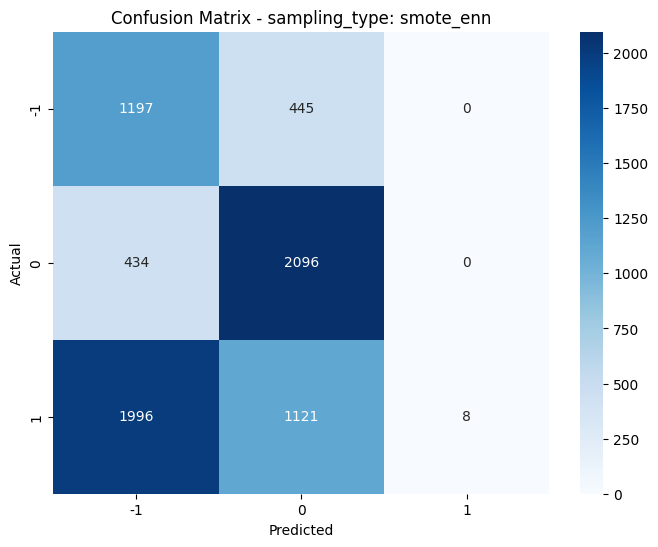

In [14]:
for method in sampling_types:
    run_experiment_balance_data(method, df=df, feature_column= 'clean_comment', target_column= 'category')